# train_rgb — Ho et al. (2017) variant

Copy of `train_rgb.ipynb` implementing the applicable methodology of
**Ho et al. 2017** (arXiv:1609.03195, *"Masses and ages for 230,000 LAMOST
giants via their carbon and nitrogen abundances"*):

1. **Mask non-stellar features** (§3.1): the 15272 Å diffuse interstellar
   band is set to `ivar = 0` so the model cannot learn extinction as a label
   proxy — critical before transferring to extincted bulge targets.
2. **Prune the reference set with cross-validation** (§3.2): stars whose
   out-of-fold residual exceeds 4× the robust scatter in **any** label are
   excised (bad reference values) and the k-fold is re-run on the survivors.
3. **Stage 2 regresses seismic mass as well as age** (§5 / Martig et al.
   2016): mass is the better-behaved target — age ∝ M⁻³ᐧ⁵ amplifies errors.
4. **Martig validity box** (§5): age statistics are quoted inside the label
   region where the C/N→age calibration physically applies; predictions
   outside it are flagged as extrapolations.

In [ ]:
# --- JAX backend selection with CPU fallback ---
# A tiny matmul probes whether the GPU backend can actually COMPILE (device
# discovery alone doesn't catch a broken CuDNN: e.g. "Loaded runtime CuDNN
# 9.5.0 but source was compiled with 9.8.0" fails only at compile time).
# On failure everything runs on CPU -- fine for this workload; the order-2
# closed-form training takes seconds. The real fix on the cluster is to load
# a matching CuDNN module (>= the version jaxlib was built against) before
# starting Jupyter, or `pip install -U nvidia-cudnn-cu12`.
import jax
import jax.numpy as jnp

try:
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend:", jax.default_backend())
except Exception as exc:
    print(f"GPU compile failed ({type(exc).__name__}) -- falling back to CPU")
    jax.config.update("jax_default_device", jax.devices("cpu")[0])
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend: CPU (fallback)")

import thecannon as tc
print("thecannon:", tc.__file__)

E0707 20:53:24.559743 1866766 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.5.0 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0707 20:53:24.563221 1866766 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.5.0 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0707 20:53:24.565034 1866766 status_macros.cc:58] INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/gpu_compiler.cc:2695) dnn_support != nullptr 
*** Begin stack trace ***
	
	
	
	
	
	
	
	
	
	

GPU compile failed (JaxRuntimeError) -- falling back to CPU
JAX backend: CPU (fallback)
thecannon: /scratch/mk27/mj8805/AnniesLasso/thecannon/__init__.py


Evo_state; kepler: rgb: 1, heb=2

In [2]:
import os
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from thecannon import continuum

In [3]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")

In [4]:
spectra = pd.read_parquet('~/rgb_clean.parquet')

In [5]:
[c for c in spectra.columns if 'age' in c.lower()]

['age_Dnu',
 'age_16_Dnu',
 'age_84_Dnu',
 'age_L',
 'age_16_L',
 'age_84_L',
 'RelAge_Dnu',
 'RelAge_L',
 'log_age_Dnu',
 'log_age_Dnu_err']

In [6]:
spectra = spectra[spectra['log_age_Dnu_err']<=0.1]

In [7]:
len(spectra)

894

In [8]:
# STAGE-1 LABELS: only quantities the spectrum constrains directly. log_age
# is NOT a spectral label any more: the split-half test (below) showed its
# pixel coefficients do not reproduce (r = +0.10, vs +0.70 for raw_teff), so
# with ~900 stars The Cannon cannot learn age from the pixels -- when it was
# in the label vector its test-step predictions just collapsed to the sample
# mean. Age is instead predicted in a SECOND STAGE from the labels the
# spectrum does measure -- c_n (the mass / dredge-up indicator) above all,
# plus teff/logg/fe_h -- see the "age from labels" cells at the bottom
# (Martig et al. 2016 approach).
INCLUDE_C_N = True
INCLUDE_CN = False    # c_fe/n_fe as separate labels: superseded by c_n
INCLUDE_O = False
INCLUDE_AL = False
INCLUDE_CE = False
INCLUDE_ND = False

spectra['c_n'] = spectra['raw_c_h'] - spectra['raw_n_h']
spectra['c_n_err'] = np.sqrt(spectra['raw_e_c_h']**2 + spectra['raw_e_n_h']**2)

LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + (['c_n'] if INCLUDE_C_N else [])
              + (['c_fe', 'n_fe'] if INCLUDE_CN else [])
              + (['o_fe'] if INCLUDE_O else [])
              + (['al_fe'] if INCLUDE_AL else [])
              + (['ce_fe'] if INCLUDE_CE else [])
              + (['nd_fe'] if INCLUDE_ND else []))
labels = spectra[LABEL_COLS]

# The wavelength/flux/ivar columns hold one array PER ROW. We need a single
# 1-D dispersion array and 2-D (n_stars, n_pixels) flux/ivar arrays -- NOT the
# raw pandas Series (a Series-of-arrays, which is what broke searchsorted).
def to_array(x):
    if isinstance(x, str):                       # stringified list (e.g. from CSV)
        return np.fromstring(x.strip("[] \n"), sep=",")
    return np.asarray(x, dtype=float)

dispersion = to_array(spectra['wavelength'].iloc[0])           # (n_pixels,)
flux = np.vstack([to_array(x) for x in spectra['flux']])       # (n_stars, n_pixels)
ivar = np.vstack([to_array(x) for x in spectra['ivar']])       # (n_stars, n_pixels)

# Sanity checks -- all must pass before normalizing.
assert dispersion.ndim == 1, dispersion.shape
assert flux.shape == ivar.shape == (len(spectra), dispersion.size)
assert np.all(np.diff(dispersion) > 0), "dispersion must be sorted ascending"
print(dispersion.shape, flux.shape, ivar.shape, dispersion.dtype)

(8575,) (894, 8575) (894, 8575) float64


In [9]:
# Integer continuum-pixel indices. Keep only those valid for this grid.
continuum_pixels = np.loadtxt(SRC / "bulge-ages-and-orbits/data/continuum.list", dtype=int, comments="#")
continuum_pixels = continuum_pixels[continuum_pixels < dispersion.size]
APOGEE_REGIONS = ([15090, 15822], [15823, 16451], [16452, 16971])

In [10]:
import jax.numpy as jnp
dispersion = jnp.array(dispersion)
flux = jnp.array(flux)
ivar = jnp.array(ivar)
continuum_pixels = jnp.array(continuum_pixels)
APOGEE_REGIONS = [jnp.array(r) for r in APOGEE_REGIONS]

In [ ]:
# NB: output is named `continuum_fit` so it doesn't shadow the imported
# `continuum` module (otherwise re-running this cell would fail).
normalized_flux, normalized_ivar, continuum_fit, metadata = continuum.normalize(
    dispersion,          # (n_pixels,) APOGEE wavelength grid
    flux,                # (n_stars, n_pixels)
    ivar,                # inverse variance, same shape
    continuum_pixels,
    L=1400, order=3,
    regions=APOGEE_REGIONS,
)

# Quick check: were the spectra already normalized, or did we just normalize them?
good = ivar > 0
print("median raw flux on good pixels:    ", np.median(flux[good]))
print("median normalized flux (should ~1):", np.median(normalized_flux[good]))

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

median raw flux on good pixels:     1373.24755859375
median normalized flux (should ~1): 0.9829885145402872


In [ ]:
# Ho+17 SS3.1: mask features NOT intrinsic to the star, so the model cannot
# learn them as label proxies. In APOGEE the main culprit is the strong
# diffuse interstellar band (DIB) at 15272 A: its strength tracks extinction,
# which correlates with distance/population -- a model that keys on it would
# transfer terribly to the extincted bulge targets. Masking = ivar -> 0 (the
# paper's convention); the pixels then drop out of training, testing, the
# censor windows and `good_pix` automatically. Add telluric-residual windows
# here if the theta diagnostic shows structure at known telluric bands.
DIB_WINDOWS = [(15260.0, 15285.0)]           # (start, end) in Angstroms
disp_np = np.asarray(dispersion)
dib_mask = np.zeros(disp_np.size, dtype=bool)
for lo, hi in DIB_WINDOWS:
    dib_mask |= (disp_np >= lo) & (disp_np <= hi)
normalized_ivar = normalized_ivar.at[:, np.where(dib_mask)[0]].set(0.0)
print(f"masked {dib_mask.sum()} pixels in {len(DIB_WINDOWS)} window(s)")

masked 118 pixels in 1 window(s)


## Build, train, and cross-validate a CannonModel (stage 1), then age from labels (stage 2)

Two-stage pipeline. **Stage 1**: k-fold cross-validated Cannon model for the
labels the spectrum constrains directly (Teff, logg, [Fe/H], [Mg/Fe], [C/N]) --
every star gets an out-of-fold prediction from a model that never saw it, and a
final model is trained on all stars for saving. **Stage 2** (bottom of the
notebook): log(age) is predicted from the out-of-fold Cannon labels with a
quadratic regression on the same folds (Martig et al. 2016 style), because the
split-half test shows the pixels themselves carry no reproducible age signal
beyond what [C/N] + Teff/logg/[Fe/H] already encode.

In [ ]:
list(labels.columns)

['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'c_n']

In [ ]:
LABEL_NAMES = list(labels.columns)

# Stage-2 target: seismic log(age), kept OUT of the spectral label vector.
age_target = spectra['log_age_Dnu'].values

# Drop stars with any non-finite label or age -- NaNs would break the fits.
finite = (np.isfinite(labels[LABEL_NAMES].values).all(axis=1)
          & np.isfinite(age_target))
finite_idx = np.where(finite)[0]

# Finite-star subset used everywhere below.
labels_f = labels.iloc[finite_idx]
flux_f = normalized_flux[finite_idx]
ivar_f = normalized_ivar[finite_idx]
truth = labels_f.values
age_f = age_target[finite_idx]

# K-fold assignment (replaces the old single 80/20 split): every star gets an
# out-of-fold prediction from a model that never saw it, and the SAME folds
# are reused by the stage-2 age regression so ages stay out-of-sample end to
# end.
K_FOLDS = 5
rng = np.random.RandomState(888)
fold = rng.permutation(len(finite_idx)) % K_FOLDS       # fold id per finite star
print(f"{finite.sum()} stars in {K_FOLDS} folds of {np.bincount(fold)} "
      f"({(~finite).sum()} dropped for non-finite labels/age)")

879 stars in 5 folds of [176 176 176 176 175] (15 dropped for non-finite labels/age)


In [ ]:
# Pixel censoring for NARROW-LINE abundance labels only: each one may only
# shape the flux at pixels near its own lines, so it cannot absorb noise
# across the other ~8000 pixels. In a censor mask, True = the label is
# censored (excluded) at that pixel.
#
# C/N labels (c_fe, n_fe, c_n) are deliberately NOT censored: CN molecular
# features blanket most of the H band, and censoring them to narrow windows
# forces the model to explain real CN-driven flux with the remaining labels --
# mostly age -- which wrecked the age recovery (k-fold age scatter
# 2.8 -> 5.3 Gyr when C/N were censored to 5% of pixels).
#
# NB the trailing comma in ('mg_fe',): without it Python iterates the STRING
# character by character and the censor list is silently empty.
#
# The windows are derived from the data rather than a line list: train a quick
# first-order (linear), uncensored probe model, then keep for each censored
# label only the KEEP_FRAC of pixels where |its linear coefficient| is
# largest, dilated by +/-DILATE pixels to cover line wings. Pixels with data
# for <80% of stars (chip gaps, band edges) are excluded first: their fits are
# unconstrained, so their |theta| is huge and meaningless and would otherwise
# eat the pixel budget. (The probe uses all finite stars, so a little
# information leaks across folds into the k-fold statistics -- but the windows
# encode line positions, physics, not noise.)
from thecannon.censoring import Censors

CENSORED_LABELS = [l for l in ('mg_fe',) if l in LABEL_NAMES]
KEEP_FRAC = 0.05     # fraction of pixels each censored label may use
DILATE = 2           # pixels of padding on each side of a kept pixel

# Pixels constrained by real data (used here and by the theta diagnostic).
good_pix = (np.asarray(ivar_f) > 0).mean(axis=0) > 0.8
print(f"{(~good_pix).sum()} of {good_pix.size} pixels have data for <80% "
      "of stars (chip gaps / band edges); excluded from windows")

probe = tc.CannonModel(
    labels_f, flux_f, ivar_f,
    tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=1),
    dispersion=dispersion)
probe.train(progressbar=False)
probe_theta = np.asarray(probe.theta)            # (n_pixels, 1 + n_labels)

def censor_mask(label):
    """True = censored. Keep the pixels where this label's linear
    coefficient is strongest, padded for line wings."""
    coef = np.abs(probe_theta[:, 1 + LABEL_NAMES.index(label)])
    coef = np.where(good_pix, coef, 0.0)         # junk pixels can't be windows
    keep = coef >= np.quantile(coef, 1.0 - KEEP_FRAC)
    for _ in range(DILATE):
        keep = keep | np.roll(keep, 1) | np.roll(keep, -1)
    return ~keep

censors = Censors(LABEL_NAMES, int(dispersion.size),
                  {l: censor_mask(l) for l in CENSORED_LABELS})
assert len(censors) == len(CENSORED_LABELS)
for l in CENSORED_LABELS:
    print(f"{l}: {int((~censors[l]).sum())}/{dispersion.size} pixels retained")

973 of 8575 pixels have data for <80% of stars (chip gaps / band edges); excluded from windows


2026-07-07 20:53:36,811 [INFO] Training 5-label CannonModel with 879 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 879 stars and 8575 pixels/star


mg_fe: 935/8575 pixels retained


In [ ]:
# Quadratic (order=2) polynomial vectorizer -- the standard Cannon choice.
# REGULARIZATION=0 uses the closed-form least-squares path. The k-fold is
# wrapped in a function because the Ho+17 pruning pass (next cell) re-runs it
# on the cleaned reference set. Progress bars are off inside the loop: tqdm
# host callbacks get baked into the compiled scan, forcing a recompile per
# fold.
ORDER = 2
REGULARIZATION = 0.0

vectorizer = tc.vectorizer.PolynomialVectorizer(
    label_names=LABEL_NAMES, order=ORDER)
print("Vectorizer terms:", vectorizer.get_human_readable_label_vector())

def run_kfold(labels_df, flux_arr, ivar_arr, fold_ids):
    """Out-of-fold Cannon predictions + test-step reduced chi^2 for every
    star: train on K-1 folds, predict the held-out fold."""
    preds = np.full((len(labels_df), len(LABEL_NAMES)), np.nan)
    chi2 = np.full(len(labels_df), np.nan)
    for k in range(K_FOLDS):
        tr = fold_ids != k
        m = tc.CannonModel(
            labels_df[tr], flux_arr[tr], ivar_arr[tr],
            vectorizer, dispersion=dispersion,
            regularization=REGULARIZATION, censors=censors)
        m.train(progressbar=False)
        p, _, meta = m.test(flux_arr[~tr], ivar_arr[~tr],
                            batch_size=32, progressbar=False)
        preds[~tr] = np.asarray(p)
        chi2[~tr] = [mm["r_chi_sq"] for mm in meta]
        print(f"  fold {k}: trained on {tr.sum()} stars, "
              f"predicted {(~tr).sum()} held-out stars")
    return preds, chi2

print("first pass (full reference set):")
val_labels, val_chi2 = run_kfold(labels_f, flux_f, ivar_f, fold)

Vectorizer terms: 1 + raw_teff + raw_logg + raw_fe_h + mg_fe + c_n + raw_teff^2 + raw_logg*raw_teff + raw_fe_h*raw_teff + mg_fe*raw_teff + c_n*raw_teff + raw_logg^2 + raw_fe_h*raw_logg + mg_fe*raw_logg + c_n*raw_logg + raw_fe_h^2 + mg_fe*raw_fe_h + c_n*raw_fe_h + mg_fe^2 + c_n*mg_fe + c_n^2
first pass (full reference set):


2026-07-07 20:56:18,082 [INFO] Training 5-label CannonModel with 703 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 703 stars and 8575 pixels/star
2026-07-07 20:58:56,194 [INFO] Training 5-label CannonModel with 703 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 703 stars and 8575 pixels/star


  fold 0: trained on 703 stars, predicted 176 held-out stars


2026-07-07 21:01:24,398 [INFO] Training 5-label CannonModel with 703 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 703 stars and 8575 pixels/star


  fold 1: trained on 703 stars, predicted 176 held-out stars


2026-07-07 21:03:52,920 [INFO] Training 5-label CannonModel with 703 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 703 stars and 8575 pixels/star


  fold 2: trained on 703 stars, predicted 176 held-out stars
  fold 3: trained on 703 stars, predicted 176 held-out stars


2026-07-07 21:06:21,347 [INFO] Training 5-label CannonModel with 704 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 704 stars and 8575 pixels/star


  fold 4: trained on 704 stars, predicted 175 held-out stars


In [ ]:
# Ho+17 SS3.2: prune the reference set using the cross-validation itself. A
# reference star whose out-of-fold residual exceeds 4x the robust scatter in
# ANY label has an unreliable reference value (bad ASPCAP fit, binarity,
# wrong evolutionary state, ...) and poisons the pixel fits it participates
# in. Excise those stars and re-run the k-fold on the survivors -- Ho+17
# excised ~4% this way. The 4-sigma threshold is deliberately looser than
# the 3-sigma plotting flag below: pruning changes the model, so it must only
# remove clear label failures, not trim the noise tail.
resid1 = val_labels - truth
med1 = np.nanmedian(resid1, axis=0)
sig1 = 1.4826 * np.nanmedian(np.abs(resid1 - med1), axis=0)
keep = (np.all(np.abs(resid1 - med1) < 4 * sig1, axis=1)
        & np.all(np.isfinite(val_labels), axis=1))
print(f"excising {(~keep).sum()} of {len(keep)} reference stars "
      f"(>4 sigma residual in at least one label)")

# Shrink every per-star array to the survivors; downstream cells see only
# the pruned sample.
finite_idx = finite_idx[keep]
labels_f = labels_f[keep]
flux_f = flux_f[keep]
ivar_f = ivar_f[keep]
truth = truth[keep]
age_f = age_f[keep]
fold = fold[keep]

print("second pass (pruned reference set):")
val_labels, val_chi2 = run_kfold(labels_f, flux_f, ivar_f, fold)

excising 79 of 879 reference stars (>4 sigma residual in at least one label)
second pass (pruned reference set):


2026-07-07 21:08:50,703 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:08:51,478 [INFO] Training 5-label CannonModel with 634 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 634 stars and 8575 pixels/star


  fold 0: trained on 634 stars, predicted 166 held-out stars


2026-07-07 21:11:09,221 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:11:09,991 [INFO] Training 5-label CannonModel with 643 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 643 stars and 8575 pixels/star


  fold 1: trained on 643 stars, predicted 157 held-out stars


...

  fold 2: trained on 637 stars, predicted 163 held-out stars


2026-07-07 21:15:39,912 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:15:40,694 [INFO] Training 5-label CannonModel with 640 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 640 stars and 8575 pixels/star


  fold 3: trained on 640 stars, predicted 160 held-out stars


2026-07-07 21:17:54,612 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:17:55,421 [INFO] Training 5-label CannonModel with 646 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 646 stars and 8575 pixels/star


  fold 4: trained on 646 stars, predicted 154 held-out stars


In [ ]:
# Optional A/B harness: score alternative (order, regularization, censoring)
# configurations with the same k-fold protocol -- every config sees identical
# folds -- so changes to the knobs above are backed by numbers, not by one
# plot looking better. Each row costs K_FOLDS trainings; the order-4 row is
# by far the slowest (330 terms/pixel, iterative L1 path). Set RUN_SWEEP=True.
RUN_SWEEP = False
if RUN_SWEEP:
    import sys
    repo_root = os.path.dirname(os.path.dirname(tc.__file__))
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    backend = matplotlib.get_backend()   # sweep_cannon forces Agg on import;
    from scripts.sweep_cannon import cross_validate, _summarize
    matplotlib.use(backend)              # restore so inline plots keep working

    CONFIGS = [                          # (order, regularization, censors)
        (2, 0.0, None),
        (2, 0.0, censors),               # the main-path configuration above
        (3, 0.0, None),
        (3, 1000.0, None),
        (4, 500.0, None),                # the old notebook configuration
    ]
    rows = []
    for order_i, reg_i, cen_i in CONFIGS:
        cv = cross_validate(
            truth, np.asarray(flux_f), np.asarray(ivar_f),
            np.asarray(dispersion), LABEL_NAMES, order_i, reg_i,
            censors=cen_i, n_splits=K_FOLDS, seed=888)
        row = {"order": order_i, "reg": reg_i,
               "censor": "none" if cen_i is None else "+".join(cen_i)}
        row.update({k: v for k, v in _summarize(cv, LABEL_NAMES).items()
                    if k.startswith("sigma_mad_") or k == "mean_r2"})
        rows.append(row)
        print(row)
    sweep_results = pd.DataFrame(rows)
    display(sweep_results)               # sigma_mad_* = robust scatter per label

In [ ]:
# Final model for downstream use, trained on ALL finite stars -- the k-fold
# models above exist only to produce honest out-of-fold statistics. This is
# the model that gets saved at the bottom of the notebook.
model = tc.CannonModel(
    labels_f, flux_f, ivar_f, vectorizer, dispersion=dispersion,
    regularization=REGULARIZATION, censors=censors)
model.train()
print("final model trained:", model.is_trained,
      "| stars:", len(finite_idx), "| labels:", len(LABEL_NAMES))

2026-07-07 21:20:12,106 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:20:12,891 [INFO] Training 5-label CannonModel with 800 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 800 stars and 8575 pixels/star


Training:   0%|          | 0/17 [00:00<?, ?it/s]

final model trained: True | stars: 800 | labels: 5


Text(0.5, 0, 'wavelength [$\\mathrm{\\AA}$]')

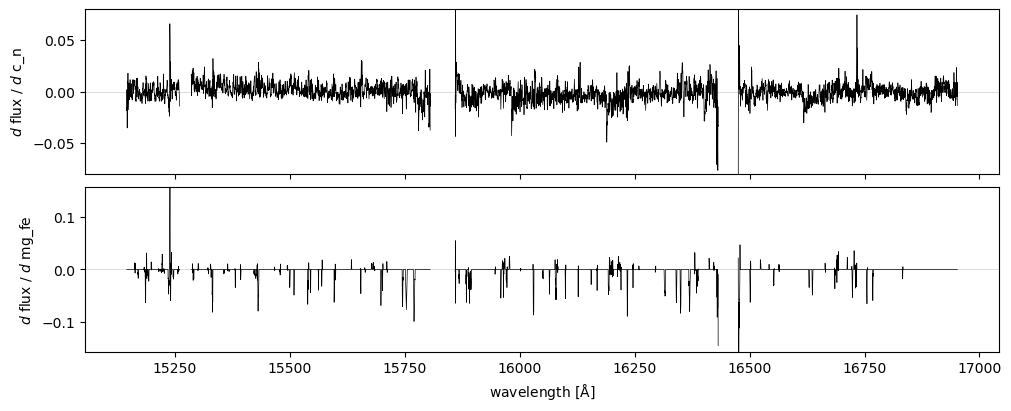

In [ ]:
# Diagnostic: where does each label actually get its spectral signal?
# First-order theta coefficients of the final model vs wavelength. Theta is
# in scaled-label units -- flux change per ~1-sigma label change -- so real
# coefficients are ~0.01-0.1. Chip-gap / band-edge pixels (no data, so theta
# is unconstrained and huge) are masked via `good_pix` from the censor cell,
# and the y-limits are robust so a few remaining spikes cannot flatten the
# plot. With c_n out of the label vector, log_age_Dnu should show dense CN
# structure across the band; a flat coefficient means no spectral leverage
# (and test-step ages that are just the sample mean).
theta_final = np.asarray(model.theta)
disp_A = np.asarray(dispersion)
show = [l for l in ('log_age_Dnu', 'c_n', 'mg_fe') if l in LABEL_NAMES]
fig, laxes = plt.subplots(len(show), 1, figsize=(10, 2.0 * len(show)),
                          sharex=True, constrained_layout=True)
for ax, l in zip(np.atleast_1d(laxes), show):
    coef = np.where(good_pix, theta_final[:, 1 + LABEL_NAMES.index(l)], np.nan)
    ax.plot(disp_A, coef, lw=0.5, color="k")
    ax.axhline(0, color="0.8", lw=0.5, zorder=-1)
    lim = 1.2 * np.nanpercentile(np.abs(coef), 99.9)
    ax.set_ylim(-lim, lim)
    ax.set_ylabel(f"$d$ flux / $d$ {l}")
ax.set_xlabel(r"wavelength [$\mathrm{\AA}$]")

In [ ]:
# Is the age structure above real signal or per-pixel fit noise? Split-half
# test: train two independent linear probes on random halves of the sample
# and correlate their first-order coefficients pixel by pixel (good pixels
# only). Real spectral leverage reproduces in both halves (r well above 0);
# noise does not (r ~ 0). raw_teff is the positive control (expect r ~ 1);
# read log_age_Dnu's r as the fraction of its coefficient structure that is
# actually age information the test step can use.
half_rng = np.random.RandomState(999)
half = half_rng.permutation(len(finite_idx)) % 2 == 0
coefs = {}
for h, sel in (("A", half), ("B", ~half)):
    p = tc.CannonModel(
        labels_f[sel], flux_f[sel], ivar_f[sel],
        tc.vectorizer.PolynomialVectorizer(label_names=LABEL_NAMES, order=1),
        dispersion=dispersion)
    p.train(progressbar=False)
    coefs[h] = np.asarray(p.theta)
for l in LABEL_NAMES:
    a = coefs["A"][good_pix, 1 + LABEL_NAMES.index(l)]
    b = coefs["B"][good_pix, 1 + LABEL_NAMES.index(l)]
    r = np.corrcoef(a, b)[0, 1]
    print(f"{l:>12}: split-half coefficient correlation r = {r:+.3f}")

2026-07-07 21:22:40,582 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:22:41,081 [INFO] Training 5-label CannonModel with 400 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 400 stars and 8575 pixels/star
2026-07-07 21:23:50,459 [WARNING] Labels 'raw_logg' and 'raw_teff' are highly correlated (rho = 0.91). This may cause very slow training times. Are both labels needed?
2026-07-07 21:23:50,467 [INFO] Training 5-label CannonModel with 400 stars and 8575 pixels/star
INFO:thecannon.model:Training 5-label CannonModel with 400 stars and 8575 pixels/star


    raw_teff: split-half coefficient correlation r = +0.469
    raw_logg: split-half coefficient correlation r = +0.562
    raw_fe_h: split-half coefficient correlation r = +0.859
       mg_fe: split-half coefficient correlation r = +0.278
         c_n: split-half coefficient correlation r = +0.774


In [ ]:
# Flag (but do NOT remove) validation outliers, so the quoted statistics stay
# honest: a star is an outlier if its residual in any label is more than
# 3 robust-sigma (1.48*MAD) from the median residual, or if any prediction is
# non-finite. Outliers are shown in grey in the one-to-one plot below but are
# still included in the bias/scatter statistics.
resids = val_labels - truth
med = np.nanmedian(resids, axis=0)
robust_sigma = 1.4826 * np.nanmedian(np.abs(resids - med), axis=0)
finite_pred = np.all(np.isfinite(val_labels), axis=1)
outlier = ~(np.all(np.abs(resids - med) < 3 * robust_sigma, axis=1) & finite_pred)
print(f"{outlier.sum()} of {len(outlier)} validation stars flagged as outliers "
      "(plotted in grey; still counted in the statistics)")

69 of 800 validation stars flagged as outliers (plotted in grey; still counted in the statistics)


In [ ]:
# Flag (but do not remove) physically unreasonable age predictions:
# outside 0-20 Gyr (log_age_Dnu is log10 of the age in Gyr).
if 'log_age_Dnu' in LABEL_NAMES:
    age_idx = LABEL_NAMES.index('log_age_Dnu')
    age_gyr = 10**val_labels[:, age_idx]
    unphysical = ~((age_gyr > 0) & (age_gyr < 20))
    print(f"{unphysical.sum()} predicted ages fall outside 0-20 Gyr")
    outlier |= unphysical

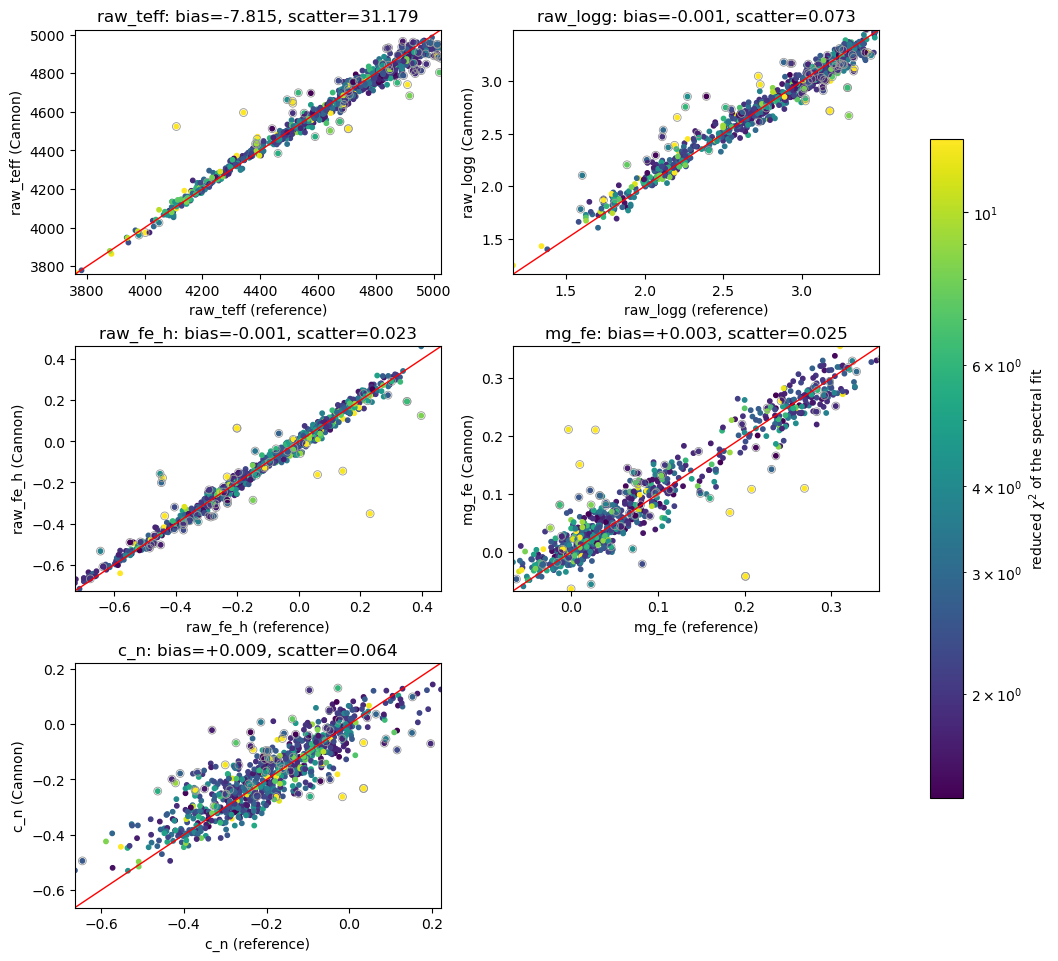

In [ ]:
# One-to-one comparison of Cannon-predicted vs ASPCAP/seismic labels on ALL
# out-of-fold predictions. No sigma clipping: the quoted bias/scatter are
# robust statistics (median and 1.48*MAD) over all finite points. Points are
# colored by the test-step reduced chi^2 -- how well the model reconstructs
# each SPECTRUM -- so poorly-fit spectra can be spotted directly; label
# outliers (from the cells above) keep a grey ring. Age is compared in log
# space (dex), where the scatter is not dominated by the oldest stars.
from matplotlib.colors import LogNorm

chi_ok = np.isfinite(val_chi2) & (val_chi2 > 0)
chi_lo, chi_hi = np.percentile(val_chi2[chi_ok], [2, 98])
chi_norm = LogNorm(vmin=chi_lo, vmax=chi_hi)     # robust limits; chi^2 is heavy-tailed

nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points; ringed outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    unit = " dex" if name == "log_age_Dnu" else ""
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}{unit}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")

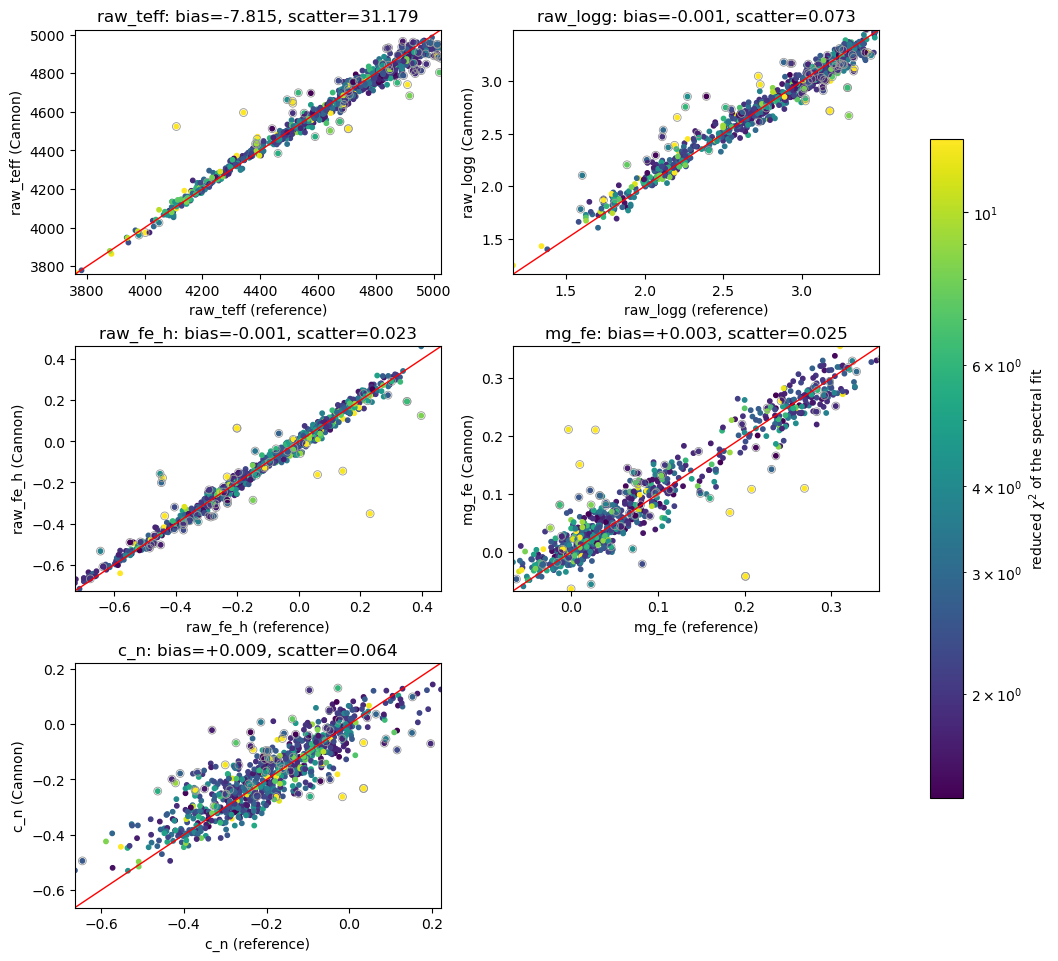

In [ ]:
# Same one-to-one comparison, but with age in LINEAR Gyr. Points are colored
# by the test-step reduced chi^2 of the spectral fit (shared color scale with
# the log-space figure above); label outliers keep a grey ring.
nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    ok = np.isfinite(x) & np.isfinite(y)
    if name == 'log_age_Dnu':
        name = 'age_Dnu'
        x = 10**x
        y = 10**y
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points; ringed outliers may fall outside.
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")

In [ ]:
np.percentile(val_chi2, 86)

np.float64(5.006746070343603)

(array([  4., 273., 243., 103.,  54.,  29.,  20.,  18.,  11.,  12.]),
 array([0.27868501, 1.18708828, 2.09549154, 3.00389481, 3.91229807,
        4.82070133, 5.7291046 , 6.63750786, 7.54591113, 8.45431439,
        9.36271766]),
 <BarContainer object of 10 artists>)

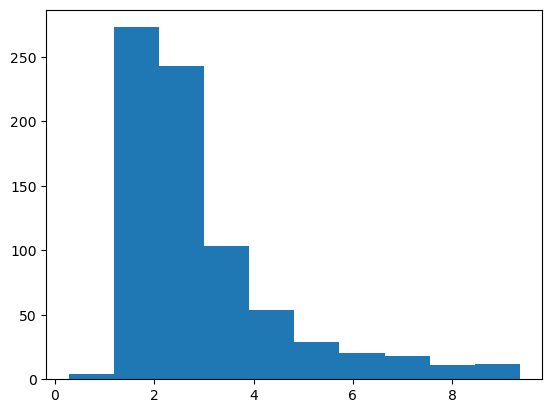

In [ ]:
normal_val_chi2 = val_chi2[val_chi2<10]
plt.hist(normal_val_chi2)

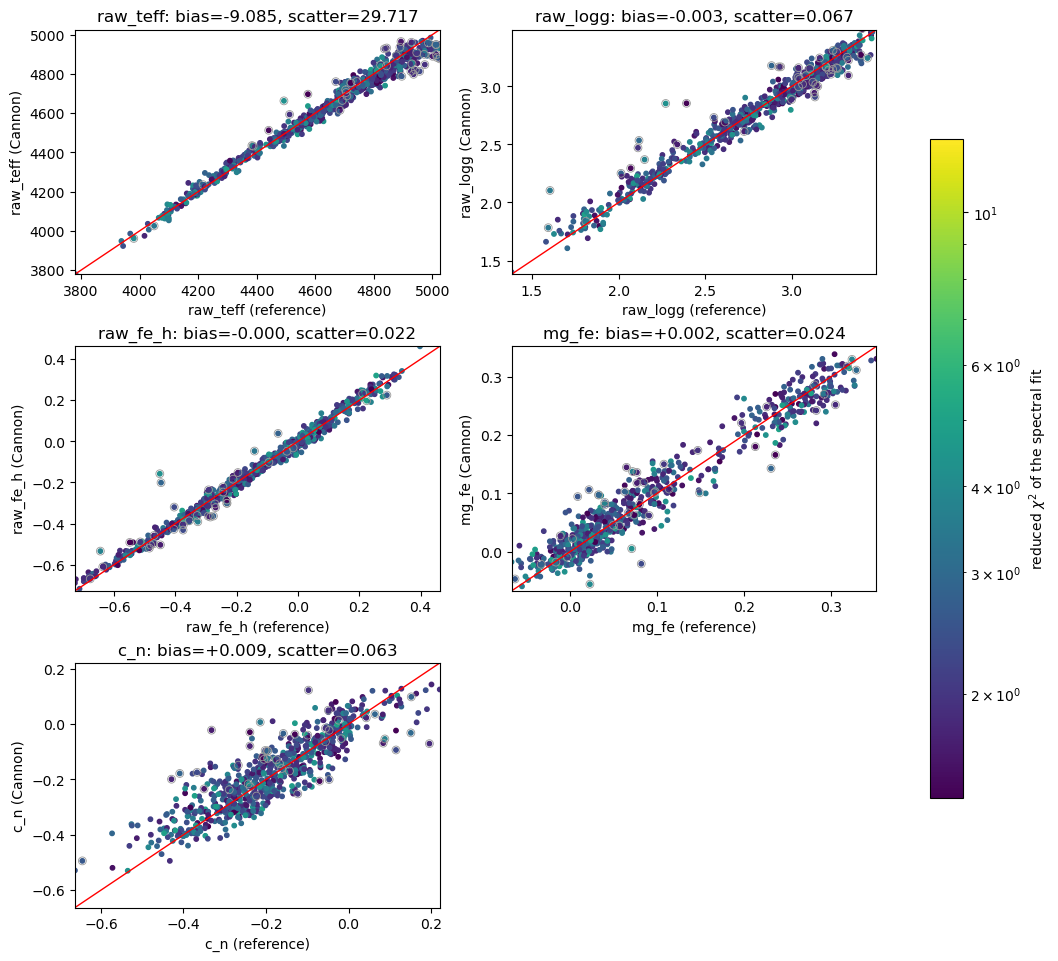

In [ ]:
# Same one-to-one comparison, but with age in LINEAR Gyr. Points are colored
# by the test-step reduced chi^2 of the spectral fit (shared color scale with
# the log-space figure above); label outliers keep a grey ring. 
# Only spectra with chisq2 <= 1.25 are included in plots and statistics.
chisq_mask = val_chi2 <= np.percentile(val_chi2, 86)

nrows = (len(LABEL_NAMES) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 2.5 * nrows + 2),
                         constrained_layout=True)
axes = axes.ravel()
for i, name in enumerate(LABEL_NAMES):
    ax = axes[i]
    x, y = truth[:, i], val_labels[:, i]
    # Only consider valid and mask for chisq2 <= 1.25
    ok = np.isfinite(x) & np.isfinite(y) & chisq_mask
    if name == 'log_age_Dnu':
        name = 'age_Dnu'
        x = 10**x
        y = 10**y
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(x[ok], y[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    ax.scatter(x[ok & outlier], y[ok & outlier], facecolor="none",
               edgecolor="0.6", linewidth=0.6, s=32)
    # Axis limits from the non-outlier points (with chisq2 cut)
    xg, yg = x[ok & ~outlier], y[ok & ~outlier]
    lims = [min(xg.min(), yg.min()), max(xg.max(), yg.max())]
    ax.plot(lims, lims, "-", color="r", lw=1)           # 1:1 line
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f"{name} (reference)")
    ax.set_ylabel(f"{name} (Cannon)")
    ax.set_title(f"{name}: bias={bias:+.3f}, scatter={scatter:.3f}")
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(axes[:len(LABEL_NAMES)]), shrink=0.75,
             label=r"reduced $\chi^2$ of the spectral fit")
    

## Stage 2: mass and age from the spectral labels (Ho+17 §5)

The split-half test shows the pixel-level age signal does not reproduce
(r = +0.10, vs +0.70 for Teff), so The Cannon cannot learn age from the
spectrum directly with ~900 stars. But RGB age is set by stellar **mass**,
which is imprinted on labels the spectrum **does** constrain: [C/N] above
all, plus Teff/logg/[Fe/H] (Martig et al. 2016). So predict log(mass) — the
better-behaved target — and log(age) from the labels with a quadratic
regression, reusing the same folds so everything is out-of-sample at both
stages.

For each target, the two rows are two different **products**:

- **Cannon labels** — via Cannon-measured labels: the path for science
  targets whose ASPCAP labels are missing or unreliable (low-SNR / extincted
  bulge spectra).
- **Reference labels (ceiling)** — the direct Martig-style regression on
  catalogue labels, usable as-is for any star with trustworthy ASPCAP
  values. No Cannon step needed for those stars.

The gap between the rows is what the Cannon relay costs. NB: apply each
regression only to the kind of features it was trained on (Cannon-to-Cannon,
ASPCAP-to-ASPCAP) — the two label scales differ subtly.

In [ ]:
# Quadratic regression target ~ f(labels), k-folded on the SAME folds as the
# spectral model. Features are standardized so the 21-term quadratic design
# is well-conditioned; rows with non-finite features (failed test-step fits)
# are excluded from both fitting and prediction.
#
# Ho+17 / Martig+16 regress MASS, not age: mass is the better-behaved target
# (age ~ M^-3.5 amplifies mass errors, and the old-star tail compresses).
# If the catalogue has a seismic mass column, log(mass) is regressed
# alongside log(age) so the two can be compared directly.
from itertools import combinations_with_replacement

def _quad_design(X):
    cols = [np.ones(len(X))]
    cols += [X[:, i] for i in range(X.shape[1])]
    cols += [X[:, i] * X[:, j]
             for i, j in combinations_with_replacement(range(X.shape[1]), 2)]
    return np.vstack(cols).T

def kfold_age_regression(features, target):
    """Out-of-fold quadratic-regression predictions of target from features."""
    ok = np.all(np.isfinite(features), axis=1) & np.isfinite(target)
    mu, sd = features[ok].mean(0), features[ok].std(0)
    Z = (features - mu) / sd
    pred = np.full(len(target), np.nan)
    for k in range(K_FOLDS):
        tr = ok & (fold != k)
        te = ok & (fold == k)
        coef, *_ = np.linalg.lstsq(_quad_design(Z[tr]), target[tr], rcond=None)
        pred[te] = _quad_design(Z[te]) @ coef
    return pred

targets = {"log_age ": age_f}
mass_cols = [c for c in spectra.columns if 'mass' in c.lower()]
if mass_cols:
    print("using seismic mass column:", mass_cols[0])
    with np.errstate(invalid="ignore"):
        mass_f = np.log10(spectra[mass_cols[0]].values.astype(float))[finite_idx]
    targets["log_mass"] = mass_f
else:
    print("no mass column found in the catalogue -- regressing age only. "
          "Consider deriving mass from the Dnu/numax scaling relations and "
          "adding it: mass is the better regression target.")

for tname, target in targets.items():
    pred = kfold_age_regression(val_labels, target)
    ceiling = kfold_age_regression(truth, target)
    for tag, pr in (("Cannon labels             ", pred),
                    ("reference labels (ceiling)", ceiling)):
        d = pr - target
        ok = np.isfinite(d)
        bias = np.median(d[ok])
        scatter = 1.4826 * np.median(np.abs(d[ok] - bias))
        print(f"{tname} from {tag}: bias={bias:+.3f}, "
              f"scatter={scatter:.3f} dex (a factor {10**scatter:.2f})")
    if tname.strip() == "log_age":
        age_pred, age_ceiling = pred, ceiling
    else:
        mass_pred, mass_ceiling = pred, ceiling

using seismic mass column: mass_Dnu
log_age  from Cannon labels             : bias=-0.031, scatter=0.210 dex (a factor 1.62)
log_age  from reference labels (ceiling): bias=-0.018, scatter=0.194 dex (a factor 1.56)
log_mass from Cannon labels             : bias=+0.010, scatter=0.061 dex (a factor 1.15)
log_mass from reference labels (ceiling): bias=+0.005, scatter=0.058 dex (a factor 1.14)


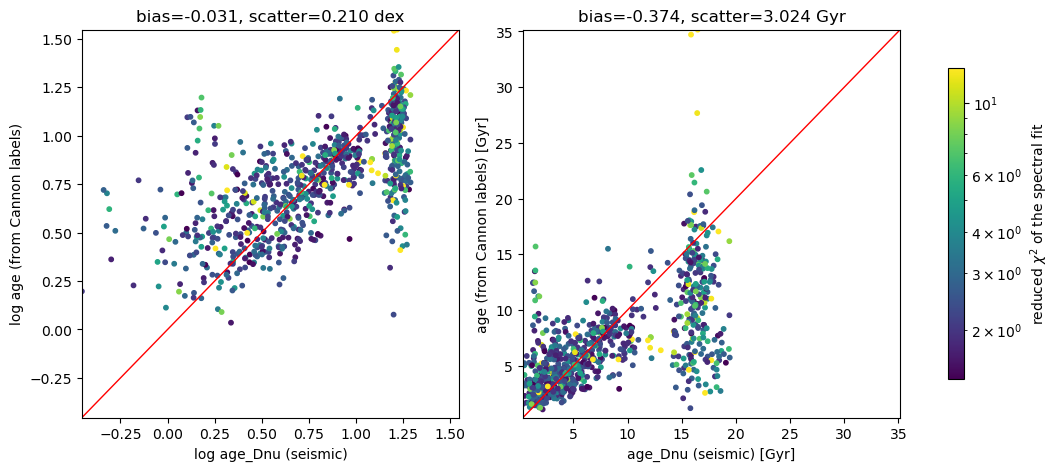

In [ ]:
# One-to-one for the two-stage ages, in log and linear space, colored by the
# stage-1 spectral-fit chi^2 (shared scale with the label figures above).
fig, axes2 = plt.subplots(1, 2, figsize=(10.5, 4.6), constrained_layout=True)
panels = [(age_f, age_pred,
           "log age_Dnu (seismic)", "log age (from Cannon labels)", " dex"),
          (10**age_f, 10**age_pred,
           "age_Dnu (seismic) [Gyr]", "age (from Cannon labels) [Gyr]", " Gyr")]
for ax, (xv, yv, xl, yl, unit) in zip(axes2, panels):
    ok = np.isfinite(xv) & np.isfinite(yv)
    d = yv[ok] - xv[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    sc = ax.scatter(xv[ok], yv[ok], c=val_chi2[ok], s=10,
                    cmap="viridis", norm=chi_norm)
    lims = [min(xv[ok].min(), yv[ok].min()), max(xv[ok].max(), yv[ok].max())]
    ax.plot(lims, lims, "-", color="r", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f"bias={bias:+.3f}, scatter={scatter:.3f}{unit}")
fig.colorbar(sc, ax=list(axes2), shrink=0.8,
             label=r"reduced $\chi^2$ of the spectral fit")

In [ ]:
# Ho+17 SS5 / Martig+16: the labels->mass/age calibration only holds for
# first-dredge-up giants inside a label box (the subset of the paper's cuts
# that applies to our label set; mg_fe stands in for [alpha/M]). Cuts are
# applied to the CANNON labels, as Ho+17 do for their science targets. Quote
# the science statistics INSIDE the box; outside it the regression
# extrapolates and the ages are not trustworthy.
L = {n: val_labels[:, LABEL_NAMES.index(n)] for n in LABEL_NAMES}
in_box = ((L['raw_teff'] > 4000) & (L['raw_teff'] < 5000)
          & (L['raw_logg'] > 1.8) & (L['raw_logg'] < 3.3)
          & (L['raw_fe_h'] > -0.8) & (L['raw_fe_h'] < 0.25)
          & (L['c_n'] > -0.6) & (L['c_n'] < 0.2)
          & (L['mg_fe'] > -0.05) & (L['mg_fe'] < 0.3))

d = age_pred - age_f
ok = np.isfinite(d)
for tag, m in (("all stars ", ok), ("inside box", ok & in_box)):
    bias = np.median(d[m])
    scatter = 1.4826 * np.median(np.abs(d[m] - bias))
    print(f"log_age, {tag}: n={m.sum()}, bias={bias:+.3f}, "
          f"scatter={scatter:.3f} dex")
print(f"{(ok & ~in_box).sum()} stars fall outside the validity box "
      "-> their ages are extrapolations")

log_age, all stars : n=800, bias=-0.031, scatter=0.210 dex
log_age, inside box: n=682, bias=-0.031, scatter=0.206 dex
118 stars fall outside the validity box -> their ages are extrapolations


In [ ]:
10**0.247

1.7660378206861644

In [ ]:
# Save the trained model to disk
model.write("scr_mk27/trained_cannon_model_rgb_ho17.pkl", overwrite=True)